# Threshold Tuning (Final Model)

No retraining needed for this one. The v8 models are already trained, we just want to see if changing the decision thresholds gets us better results.

Model A threshold controls how aggressively we flag cancellations. Model B threshold controls how aggressively we flag delays. We used 0.5 for both throughout v5-v8 and never actually questioned it. This notebook tests every combination on the val set to find the best one, then runs it on test exactly once.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import joblib
import os
warnings.filterwarnings('ignore')

from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_recall_fscore_support)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

## Load the v8 Models

Loading the best models from v8.

In [3]:
model_a = joblib.load('./models/model_a_v8.pkl')
model_b = joblib.load('./models/model_b_v8.pkl')
print('models loaded')

models loaded


## Load Data

Same dataset as v8, just need the val and test splits.

In [4]:
df = pd.read_parquet('../../../1_download_data/cleansed/modeling_dataset.parquet')

val  = df[df['split'] == 'val']
test = df[df['split'] == 'test']

features = [
    'dep_hour', 'Distance', 'tmpf', 'vsby', 'sknt', 'p01i', 'relh', 'gust',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos',
    'is_early_morning', 'is_evening', 'is_summer', 'is_holiday_season',
    'high_wind', 'low_visibility', 'precip_light', 'precip_moderate',
    'precip_heavy', 'weather_severity',
    'Airline_enc', 'Origin_enc', 'region_enc', 'weather_source_enc',
    'airline_delay_rate', 'airline_cancel_rate',
    'airport_delay_rate', 'airport_cancel_rate',
    'lag1_delay_rate', 'lag1_cancel_rate', 'lag1_volume',
    'cancelled_yesterday', 'hourly_flights', 'airport_operations',
    'ops_per_runway', 'num_runways', 'max_runway_length_ft', 'airport_elevation',
    'lag1m_carrier_delay', 'lag1m_weather_delay', 'lag1m_nas_delay',
    'lag1m_late_aircraft_delay', 'lag1m_security_delay','month_avg_cancel_rate', 'month_avg_delay_rate','season_avg_cancel_rate', 'season_avg_delay_rate'
]
features = [f for f in features if f in df.columns]

X_val  = val[features].fillna(val[features].median())
X_test = test[features].fillna(val[features].median())

y_val_true  = val['target'].astype(int).values
y_test_true = test['target'].astype(int).values

# compute probabilities once and reuse for all threshold combos
# this is much faster than calling predict_proba inside the loop
prob_cancel_val = model_a.predict_proba(X_val)[:, 1]
prob_delay_val  = model_b.predict_proba(X_val)[:, 1]
print('probabilities computed')

probabilities computed


## Testing All Threshold Combinations

Testing every combination of thresh_a (0.2 to 0.5) and thresh_b (0.3 to 0.6) on the val set. 49 combinations total. Once we find the best combo we run it on test exactly once.

In [5]:
thresholds_a = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
thresholds_b = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

results = []

for ta in thresholds_a:
    for tb in thresholds_b:
        # apply thresholds to precomputed probabilities
        cancelled = prob_cancel_val >= ta
        delayed   = prob_delay_val  >= tb
        y_pred = np.where(cancelled, 2, np.where(delayed, 1, 0))

        mf1 = f1_score(y_val_true, y_pred, average='macro')

        p, r, f, _ = precision_recall_fscore_support(y_val_true, y_pred,
                                                      labels=[0, 1, 2],
                                                      zero_division=0)
        results.append({
            'thresh_a': ta, 'thresh_b': tb,
            'val_macro_f1':      round(mf1, 4),
            'ontime_recall':     round(r[0], 3),
            'delayed_recall':    round(r[1], 3),
            'cancelled_recall':  round(r[2], 3),
            'cancelled_precision': round(p[2], 3),
        })

results_df = pd.DataFrame(results).sort_values('val_macro_f1', ascending=False)
print('top 10 combos:')
print(results_df.head(10).to_string(index=False))

top 10 combos:
 thresh_a  thresh_b  val_macro_f1  ontime_recall  delayed_recall  cancelled_recall  cancelled_precision
     0.50      0.60        0.4607          0.861           0.364             0.150                0.170
     0.45      0.60        0.4586          0.859           0.357             0.174                0.144
     0.50      0.55        0.4570          0.795           0.463             0.150                0.170
     0.45      0.55        0.4553          0.793           0.455             0.174                0.144
     0.40      0.60        0.4545          0.856           0.347             0.201                0.120
     0.40      0.55        0.4516          0.791           0.445             0.201                0.120
     0.35      0.60        0.4488          0.851           0.335             0.236                0.102
     0.35      0.55        0.4465          0.787           0.431             0.236                0.102
     0.50      0.50        0.4429          0.710 

## Cancelled Recall vs Macro F1

There is a consistent tradeoff: lower thresh_a catches more cancellations but hurts overall F1. This plot shows where the sweet spot is across all 49 combinations.

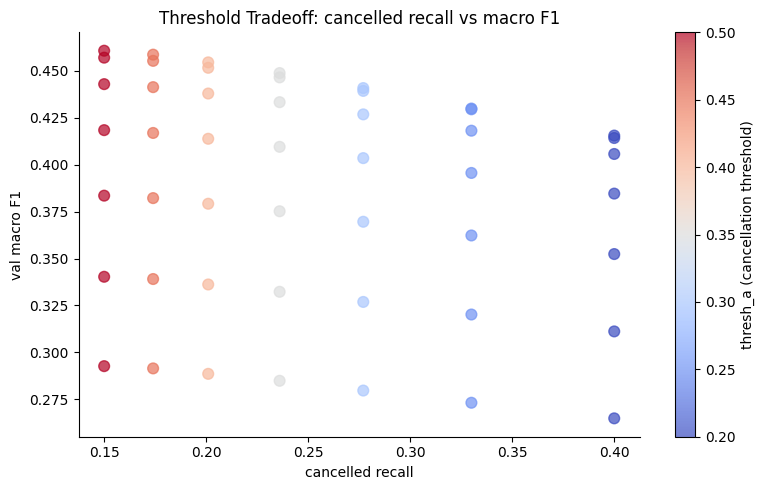

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(results_df['cancelled_recall'], results_df['val_macro_f1'],
                c=results_df['thresh_a'], cmap='coolwarm', alpha=0.7, s=60)
plt.colorbar(sc, ax=ax, label='thresh_a (cancellation threshold)')
ax.set_xlabel('cancelled recall')
ax.set_ylabel('val macro F1')
ax.set_title('Threshold Tradeoff: cancelled recall vs macro F1')
plt.tight_layout()
plt.show()

## Test Set Results

Best combo from val, run on test once.

In [7]:
best    = results_df.iloc[0]
ta_best = best['thresh_a']
tb_best = best['thresh_b']
print(f'best combo: thresh_a={ta_best}, thresh_b={tb_best}')
print(f'val macro F1: {best["val_macro_f1"]}')

# run on test exactly once
prob_cancel_test = model_a.predict_proba(X_test)[:, 1]
prob_delay_test  = model_b.predict_proba(X_test)[:, 1]

cancelled_test = prob_cancel_test >= ta_best
delayed_test   = prob_delay_test  >= tb_best
y_test_pred    = np.where(cancelled_test, 2, np.where(delayed_test, 1, 0))

mf1_test = f1_score(y_test_true, y_test_pred, average='macro')
print(f'\ntest macro F1: {mf1_test:.4f}')
print(classification_report(y_test_true, y_test_pred,
      target_names=['on_time', 'delayed', 'cancelled'], zero_division=0))

best combo: thresh_a=0.5, thresh_b=0.6
val macro F1: 0.4607

test macro F1: 0.4477
              precision    recall  f1-score   support

     on_time       0.82      0.80      0.81   3091391
     delayed       0.38      0.38      0.38    863057
   cancelled       0.12      0.20      0.15    123191

    accuracy                           0.69   4077639
   macro avg       0.44      0.46      0.45   4077639
weighted avg       0.71      0.69      0.70   4077639



## Threshold 0.5/0.5 vs Best Tuned Thresholds

How much did tuning actually help over the standard 0.5/0.5 starting point?

In [2]:
# default thresholds for comparison
cancelled_def = model_a.predict_proba(X_test)[:, 1] >= 0.5
delayed_def   = model_b.predict_proba(X_test)[:, 1] >= 0.5
y_default     = np.where(cancelled_def, 2, np.where(delayed_def, 1, 0))
mf1_default   = f1_score(y_test_true, y_default, average='macro')

comparison = pd.DataFrame({
    'model':         ['v8 (0.5/0.5)', f'v8 tuned ({ta_best}/{tb_best})'],
    'test macro F1': [round(mf1_default, 4), round(mf1_test, 4)],
})
print(comparison.to_string(index=False))

             model  test macro F1
      v8 (0.5/0.5)         0.4278
v8 tuned (0.5/0.6)         0.4477


## Confusion Matrix

Final model on test set with tuned thresholds.

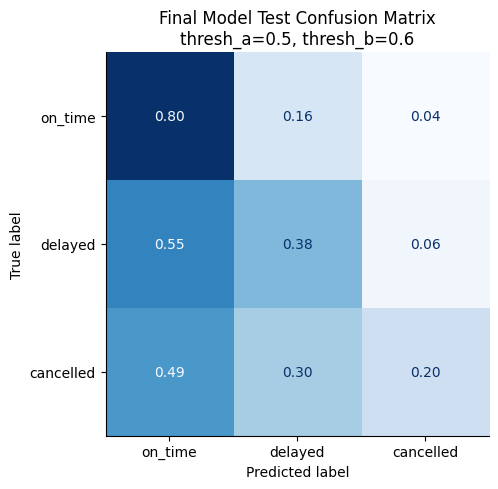

saved final_confusion_matrix.png


In [9]:
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_true, y_test_pred,
    display_labels=['on_time', 'delayed', 'cancelled'],
    ax=ax, colorbar=False, cmap='Blues',
    normalize='true',
    values_format='.2f'
)
ax.set_title(f'Final Model Test Confusion Matrix\nthresh_a={ta_best}, thresh_b={tb_best}')
plt.tight_layout()
os.makedirs('./results_visuals', exist_ok=True)
plt.savefig('./results_visuals/final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved final_confusion_matrix.png')

## Feature Importance

Same models as v8 so feature importance hasn't changed, but including it here for completeness.

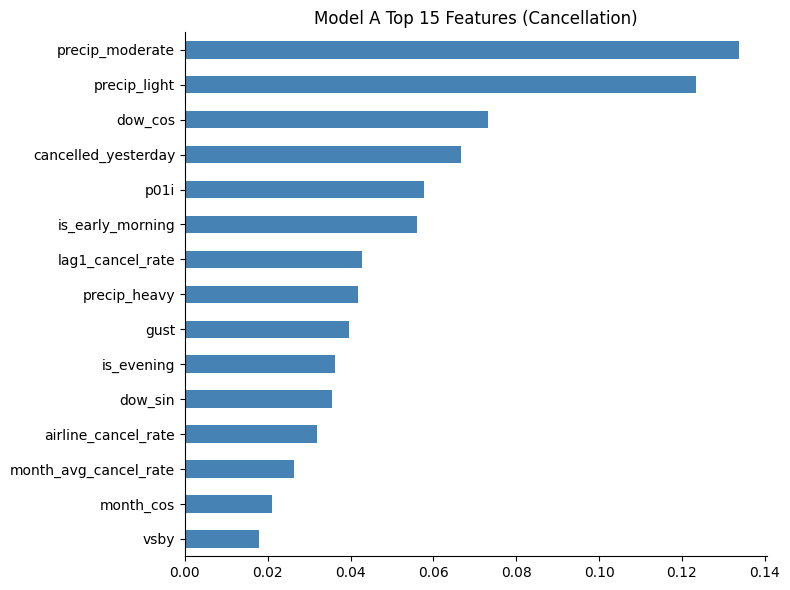

saved final_feature_importance_model_a.png


In [10]:
# model A: what drives cancellation predictions
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_a = pd.Series(model_a.feature_importances_, index=features).sort_values(ascending=False).head(15)
feat_imp_a.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Model A Top 15 Features (Cancellation)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('./results_visuals/final_feature_importance_model_a.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved final_feature_importance_model_a.png')

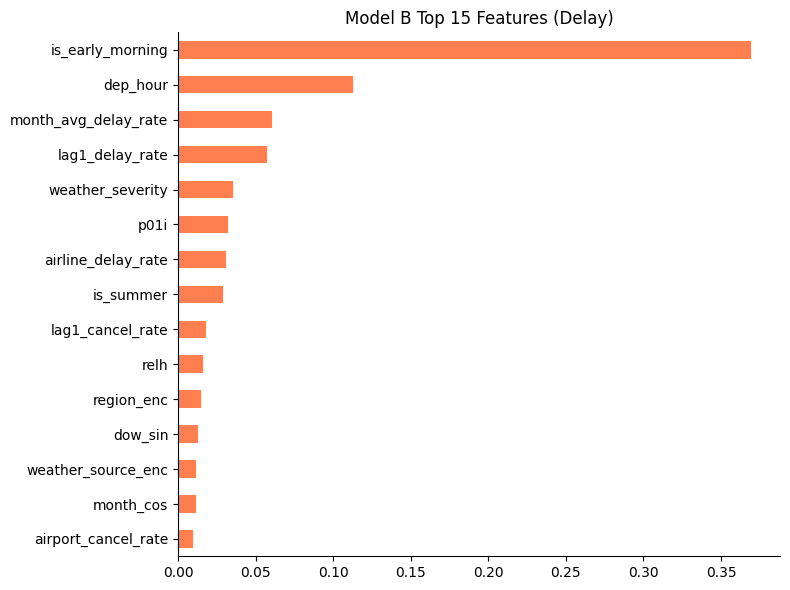

saved final_feature_importance_model_b.png


In [11]:
# model B: what drives delay predictions
fig, ax = plt.subplots(figsize=(8, 6))
feat_imp_b = pd.Series(model_b.feature_importances_, index=features).sort_values(ascending=False).head(15)
feat_imp_b.plot(kind='barh', ax=ax, color='coral')
ax.set_title('Model B Top 15 Features (Delay)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('./results_visuals/final_feature_importance_model_b.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved final_feature_importance_model_b.png')

                model  test macro F1
      v1 flights only         0.2954
          v2 +weather         0.3594
          v3 +weights         0.3770
              v4 +spw         0.2614
      v5 cascade +spw         0.3582
            v6 +SMOTE         0.4152
          v7 new data         0.4199
             v8 tuned         0.4278
v8 tuned + thresholds         0.4477


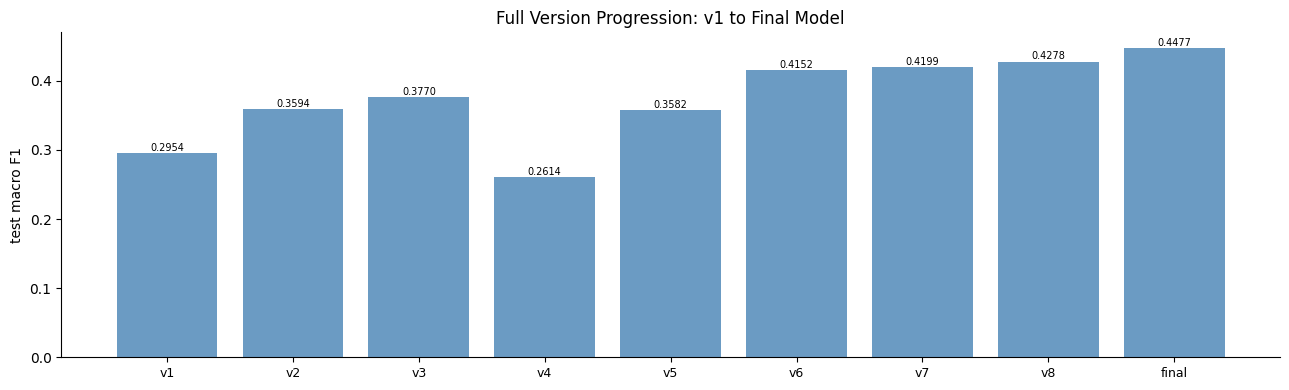

In [15]:
comparison_full = pd.DataFrame({
    'model': ['v1 flights only', 'v2 +weather', 'v3 +weights',
              'v4 +spw', 'v5 cascade +spw', 'v6 +SMOTE',
              'v7 new data', 'v8 tuned', 'v8 tuned + thresholds'],
    'test macro F1': [0.2954, 0.3594, 0.3770, 0.2614, 0.3582,
                      0.4152, 0.4199, 0.4278, round(mf1_test, 4)],
})
print(comparison_full.to_string(index=False))

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(9)
ax.bar(x, comparison_full['test macro F1'], color='steelblue', alpha=0.8)
for i, v in enumerate(comparison_full['test macro F1']):
    ax.text(i, v + 0.003, f'{v:.4f}', ha='center', fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels(['v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'final'], fontsize=9)
ax.set_ylabel('test macro F1')
ax.set_title('Full Version Progression: v1 to Final Model')
plt.tight_layout()
plt.show()




## Summary

Threshold tuning pushed test F1 from 0.4278 to 0.4477 without any retraining, just by changing thresh_b from 0.5 to 0.6. The best combo was thresh_a=0.5, thresh_b=0.6.

The scatter plot confirms the tradeoff we saw throughout: lower thresh_a catches more cancellations but hurts macro F1. The sweet spot ends up keeping thresh_a at 0.5 and only loosening thresh_b, which means the model is more conservative about flagging delays rather than changing how it handles cancellations at all.

The final model is saved as cascade_final.pkl with the tuned thresholds baked in, so anyone loading it will automatically get the best configuration.

## Save Models

Saving the final models and the full cascade bundle with the tuned thresholds baked in. The bundle is what you would load in production to run new predictions.

In [14]:
bundle = {
    'model_a':  model_a,
    'model_b':  model_b,
    'features': features,
    'thresh_a': ta_best,
    'thresh_b': tb_best,
}
joblib.dump(bundle, './models/cascade_final.pkl')
print('saved cascade_final.pkl')

saved cascade_final.pkl
